# Visualisation (EDA)

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import label

In [3]:
df_1 = pd.read_csv("data/fraudTrain.csv", sep=",")
df_2 = pd.read_csv("data/fraudTest.csv", sep=",")
df_2 = df_2[df_2["is_fraud"] != 0]
df = pd.concat([df_1, df_2], axis=0, ignore_index=True)

Augmentation des cas de fraude dans le dataset

In [4]:
df["is_fraud"].value_counts(normalize=True)

is_fraud
0    0.992569
1    0.007431
Name: proportion, dtype: float64

On remarque qu'on a un dataset très déséquilibré

In [5]:
df.sample(5)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
767143,767143,2019-11-24 16:09:05,3597926034019603,fraud_Turner and Sons,shopping_pos,2.42,Derrick,Flores,M,83690 Nicholas Ports Apt. 846,...,35.2229,-89.5518,9496,Furniture conservator/restorer,1993-03-23,9f987049396d9b3396031942b690972c,1353773345,35.958019,-90.299091,0
400445,400445,2019-07-01 03:36:53,30131826429364,"fraud_Cremin, Hamill and Reichel",misc_pos,85.66,Brianna,Foley,F,57256 Raymond Ports,...,35.9335,-84.1481,391389,"Designer, industrial/product",1994-04-22,14c64433fee7adfa085ca552b2dec399,1341113813,36.918835,-83.745710,0
697204,697204,2019-10-24 22:55:02,4939976756738216,"fraud_Schuppe, Nolan and Hoeger",shopping_pos,8.43,Michelle,Johnston,F,3531 Hamilton Highway,...,26.4215,-99.0025,18128,IT trainer,1990-11-07,742857d92da4e48b5e82eca501ea51f3,1351119302,25.533509,-99.341087,0
738770,738770,2019-11-11 16:04:38,4855853415727304322,fraud_Labadie LLC,personal_care,84.47,Justin,Aguilar,M,184 Miller Manors,...,44.8232,-89.1665,3223,Senior tax professional/tax inspector,1954-06-30,2806391ebc9bcd6a50eac6df00978fd6,1352649878,45.770336,-89.914064,0
270448,270448,2019-05-13 17:37:35,3545109339866548,fraud_Schroeder Group,health_fitness,9.49,Keith,Sanders,M,8030 Beck Motorway,...,33.4783,-90.5142,2870,Chartered public finance accountant,1999-03-05,6e127a758786d1d2f509df30fbf0854e,1336930655,33.033521,-89.758410,0


In [6]:
df.drop(["merch_lat","merch_long","lat","long",'Unnamed: 0','trans_num','cc_num','last','first','street'], axis=1, inplace=True)

Suppression des colonnes qui vont faire du bruit dans le modèle

<Axes: ylabel='count'>

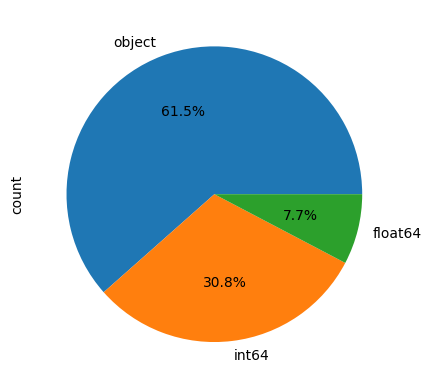

In [7]:
df.dtypes.value_counts().plot.pie(autopct='%1.1f%%')

In [8]:
print(df.duplicated().sum().sum())

0


Pas de valeur dupliquées

In [9]:
df.describe(include="all")

,trans_date_trans_time,merchant,category,amt,gender,city,state,zip,city_pop,job,dob,unix_time,is_fraud
count,1298820,1298820,1298820,1.298820e+06,1298820,1298820,1298820,1.298820e+06,1.298820e+06,1298820,1298820,1.298820e+06,1.298820e+06
unique,1276936,693,14,NaN,2,906,51,NaN,NaN,497,984,NaN,NaN
top,2019-04-22 16:02:01,fraud_Kilback LLC,gas_transport,NaN,F,Birmingham,TX,NaN,NaN,Film/video editor,1977-03-23,NaN,NaN
freq,4,4418,131813,NaN,711027,5642,94989,NaN,NaN,9787,5651,NaN,NaN
mean,NaN,NaN,NaN,7.110743e+01,NaN,NaN,NaN,4.879912e+04,8.878432e+04,NaN,NaN,1.349294e+09,7.430591e-03
std,NaN,NaN,NaN,1.620471e+02,NaN,NaN,NaN,2.689293e+04,3.018400e+05,NaN,NaN,1.289102e+07,8.588005e-02
min,NaN,NaN,NaN,1.000000e+00,NaN,NaN,NaN,1.257000e+03,2.300000e+01,NaN,NaN,1.325376e+09,0.000000e+00
25%,NaN,NaN,NaN,9.660000e+00,NaN,NaN,NaN,2.623700e+04,7.430000e+02,NaN,NaN,1.338761e+09,0.000000e+00
50%,NaN,NaN,NaN,4.758000e+01,NaN,NaN,NaN,4.817400e+04,2.456000e+03,NaN,NaN,1.349296e+09,0.000000e+00
75%,NaN,NaN,NaN,8.331000e+01,NaN,NaN,NaN,7.201100e+04,2.032800e+04,NaN,NaN,1.359494e+09,0.000000e+00


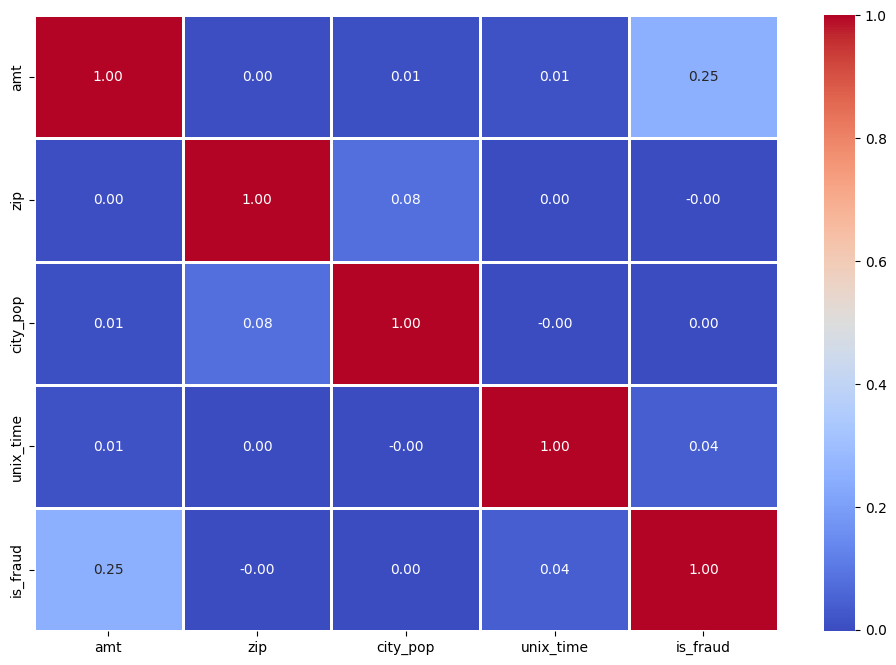

In [10]:
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
#kot = corr[(corr !=1.000) & ((corr >=0.4) | (corr <=(-0.2)))]
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=1,
            )
plt.show()

Pas de corrélation entre nos données quantitative

# Preprocessing

In [11]:
# Prétraitement
from sklearn.preprocessing import StandardScaler, MinMaxScaler,LabelEncoder,OrdinalEncoder,OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [12]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])
df['age_at_transaction'] = (df['trans_date_trans_time'] - df['dob']).dt.days / 365.25
df['age_at_transaction'] = df['age_at_transaction'].round(0).astype(int)
df['age_at_transaction']

0          31
1          41
2          57
3          52
4          33
           ..
1298815    62
1298816    62
1298817    62
1298818    62
1298819    62
Name: age_at_transaction, Length: 1298820, dtype: int64

On peut déduire l'age de la personne qui a déclaré la fraude avec sa date de naissance et le timestamp du moment de la fraude.

In [13]:
"""# S'assurer que la colonne est bien au format datetime
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# Extraire les composants standards
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.dayofweek # 0=Lundi, 6=Dimanche
df['month'] = df['trans_date_trans_time'].dt.month
df['is_night'] = df['hour'].apply(lambda x: 1 if (x <= 6 or x >= 22) else 0) # Binaire nuit/jour

# On crée les composantes Sinus et Cosinus pour l'heure (cycle de 24)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# On crée les composantes Sinus et Cosinus pour le jour (cycle de 7)
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Supprimer la colonne originale qui pose problème
df = df.drop(columns=['trans_date_trans_time','hour', 'day_of_week','dob'])"""
df = df.drop(columns=['trans_date_trans_time','dob'])

In [14]:
df_sav = df.copy()

In [15]:
 #"hour_sin", "hour_cos", "day_sin", "day_cos"
numeric_features = ["amt", "zip", "city_pop", "age_at_transaction",'unix_time']
categorical_features_non_ord = ["state", "city","gender","category","merchant","job"]

In [16]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_non_ord_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinay", LabelEncoder())
])

# 1. Définition propre du ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        # Pour les colonnes numériques
        ('num', StandardScaler(), numeric_features),
        # Pour les colonnes catégorielles (utilise OrdinalEncoder pour le non-supervisé)
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_features_non_ord)
    ],
    remainder='drop' # On ignore les colonnes non listées (comme 'zip' si elle pose problème)
)

In [17]:
df.drop('is_fraud', axis=1, inplace=True)

In [18]:
# Modèles de Machine Learning
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor,IsolationForest
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, auc,roc_auc_score,precision_recall_curve
from sklearn.cluster import KMeans

In [19]:
model_IsoForest = IsolationForest(
    n_estimators=100,
    contamination=0.01, # On cible tes 1%
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)

# 1. Pipeline uniquement pour le nettoyage
preprocessor_pipe = Pipeline([
    ('preprocessor', preprocessor)
])

# 2. On transforme les données
X_transformed = preprocessor_pipe.fit_transform(df)

In [20]:
model_IsoForest.fit(X_transformed)
y_pred = model_IsoForest.predict(X_transformed)

In [21]:
df_final = pd.DataFrame(y_pred, columns=['predictions'])

In [22]:
df_final.value_counts()

predictions
 1             1285831
-1               12989
Name: count, dtype: int64

In [23]:
df_final['predictions'] = df_final['predictions'].map({-1:1,1:0})

              precision    recall  f1-score   support

           0       0.99      0.99      0.99   1289169
           1       0.15      0.20      0.17      9651

    accuracy                           0.99   1298820
   macro avg       0.57      0.60      0.58   1298820
weighted avg       0.99      0.99      0.99   1298820



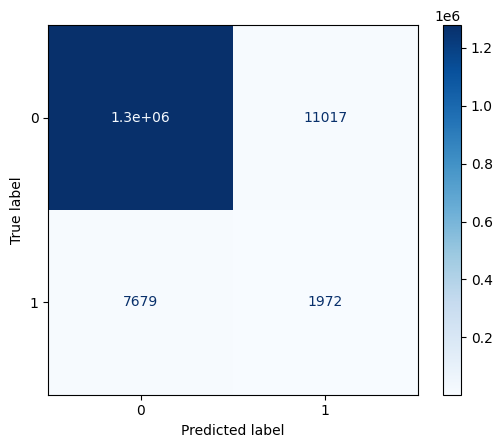

In [24]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Afficher les métriques clés (Précision, Rappel, F1-Score)
print(classification_report(df_sav['is_fraud'], df_final['predictions']))

# Visualiser la matrice de confusion de manière pro
ConfusionMatrixDisplay.from_predictions(df_sav['is_fraud'], df_final['predictions'],cmap='Blues')

              precision    recall  f1-score   support

           0       0.99      0.99      0.99   1289169
           1       0.08      0.11      0.09      9651

    accuracy                           0.98   1298820
   macro avg       0.54      0.55      0.54   1298820
weighted avg       0.99      0.98      0.99   1298820


<sklearn.metrics._plot.confusion_matrix.ConfusionMatrixDisplay at 0x1dfaa252190>
<Figure size 640x480 with 2 Axes>

In [25]:
import joblib
from sklearn.pipeline import Pipeline

# On crée un pipeline qui combine le préprocesseur et le modèle déjà entraîné
# On fait ça pour permettre au fichier .pkl de savoir comment transformer les données avant de prédire
pipe_unsup = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", model_IsoForest)
])

# 2. Sauvegarde du pipeline complet en .pkl
joblib.dump(pipe_unsup, 'model_unsup_final.pkl')

print("Modèle et pipeline sauvegardés")

Modèle et pipeline sauvegardés
